
# 04 - AdamW  (Dynamic LR + Early Stopping + Checkpoint )

notebook runs new training run for SMPL-X VQ-VAE with:

- optimizer: **AdamW**
- max epochs: **1000**
- dynamic LR scheduling: **ReduceLROnPlateau**
- early stopping: stop if no val loss improvement for **75 epochs**
- checkpointing: every **25 epochs**, keep only latest **10** periodic checkpoints



In [1]:

import io
import json
import pickle
import random
import time
from collections import OrderedDict
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython.display import display, Markdown, Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from smplx_gif_renderer import SMPLXGifRenderer


In [2]:

ROOT = Path.cwd()
DATA_DIR = ROOT / 'DATA' / 'SignAvatars' / 'how2sign_pkls_cropTrue_shapeTrue'
ARTIFACT_DIR = ROOT / 'artifacts' / '04_adamw_dynamiclr_earlystop_1000'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Missing data directory: {DATA_DIR}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('CUDA GPU:', torch.cuda.get_device_name(torch.cuda.current_device()))
print('Artifacts:', ARTIFACT_DIR)

SMPLX_KEY = 'smplx'
SMPLX_FEATURE_SLICE = slice(0, 169)
WINDOW_SIZE = 64
PRELOAD_ALL_IN_RAM = True

EPOCHS = 1000
BATCH_SIZE = 6144
NUM_WORKERS = 0 if PRELOAD_ALL_IN_RAM else 4

LR_INIT = 1e-4
WEIGHT_DECAY = 0.0

LAMBDA_FEATURE = 1.0
LAMBDA_VELOCITY = 0.5
LAMBDA_COMMIT = 0.02
GRAD_CLIP_NORM = 1.0

EARLY_STOP_PATIENCE = 75
EARLY_STOP_MIN_DELTA = 1e-5

SCHED_FACTOR = 0.5
SCHED_PATIENCE = 12
SCHED_COOLDOWN = 2
SCHED_MIN_LR = 1e-6

CHECKPOINT_EVERY = 25
MAX_CHECKPOINTS_TO_KEEP = 10

RENDER_SAMPLES_AFTER_TRAIN = True
NUM_RENDER_SAMPLES = 2

AMP_DTYPE = torch.bfloat16 if (DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported()) else torch.float16


Device: cuda
CUDA GPU: NVIDIA GeForce RTX 4090
Artifacts: /home/cem/tez/exp/artifacts/04_adamw_dynamiclr_earlystop_1000


In [3]:

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu', weights_only=False)
        return super().find_class(module, name)


def load_pkl_any(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except Exception:
        with open(path, 'rb') as f:
            return CPU_Unpickler(f).load()


def extract_smplx_features(obj, *, key: str = SMPLX_KEY, feature_slice: slice = SMPLX_FEATURE_SLICE) -> np.ndarray:
    if not isinstance(obj, dict):
        raise TypeError(f'Expected dict object, got {type(obj)}')
    if key not in obj:
        raise KeyError(f"Key '{key}' not found. Keys: {sorted(obj.keys())[:20]}")

    arr = np.asarray(obj[key], dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f'Expected [T, C], got {arr.shape}')

    arr = arr[:, feature_slice]
    if arr.shape[1] <= 0:
        raise ValueError('Feature slice produced empty channels.')

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr


def estimate_feature_stats(file_list, *, max_files: int = 300, max_frames_per_file: int = 200, seed: int = SEED):
    rng = np.random.default_rng(seed)
    subset = list(file_list)
    if len(subset) > max_files:
        pick = rng.choice(len(subset), size=max_files, replace=False)
        subset = [subset[i] for i in pick]

    chunks = []
    for fp in subset:
        arr = extract_smplx_features(load_pkl_any(fp))
        if len(arr) == 0:
            continue
        if len(arr) > max_frames_per_file:
            idx = rng.choice(len(arr), size=max_frames_per_file, replace=False)
            arr = arr[idx]
        chunks.append(arr)

    if not chunks:
        raise RuntimeError('No frames found while estimating stats.')

    cat = np.concatenate(chunks, axis=0)
    mean = cat.mean(axis=0).astype(np.float32)
    std = np.clip(cat.std(axis=0).astype(np.float32), 1e-6, None)
    return mean, std


class MotionDatasetVQSMPLX(Dataset):
    # Dataset with optional full RAM preload; returns normalized windows [T, C].
    def __init__(self, file_list, *, mean: np.ndarray, std: np.ndarray, win_size: int = WINDOW_SIZE,
                 max_cache_files: int = 32, max_resample_tries: int = 24, preload_all: bool = False):
        self.win_size = int(win_size)
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)
        self.max_cache_files = int(max_cache_files)
        self.max_resample_tries = int(max_resample_tries)
        self.preload_all = bool(preload_all)

        src_files = [Path(fp) for fp in file_list]
        if len(src_files) == 0:
            raise RuntimeError('No input files were provided.')

        self.file_list = []
        self._cache = OrderedDict()
        self._all_arr = []

        if self.preload_all:
            total_bytes = 0
            for fp in src_files:
                arr = extract_smplx_features(load_pkl_any(fp))
                if arr.shape[0] < self.win_size:
                    continue
                arr = np.ascontiguousarray(arr.astype(np.float32, copy=False))
                self.file_list.append(fp)
                self._all_arr.append(arr)
                total_bytes += int(arr.nbytes)

            if len(self.file_list) == 0:
                raise RuntimeError('No valid clips >= win_size were found for preload mode.')
            print(f'RAM preload complete: {len(self.file_list)} clips | approx {total_bytes/(1024**3):.2f} GiB float32')
        else:
            self.file_list = src_files

    def __len__(self):
        return len(self.file_list)

    def _get_arr(self, idx: int) -> np.ndarray:
        if self.preload_all:
            return self._all_arr[idx]

        fp = self.file_list[idx]
        k = str(fp)
        if k in self._cache:
            arr = self._cache.pop(k)
            self._cache[k] = arr
            return arr

        arr = extract_smplx_features(load_pkl_any(fp))
        self._cache[k] = arr
        if len(self._cache) > self.max_cache_files:
            self._cache.popitem(last=False)
        return arr

    def _try_sample(self, file_idx: int):
        arr = self._get_arr(file_idx)
        if arr.shape[0] < self.win_size:
            return None
        max_start = arr.shape[0] - self.win_size
        start = 0 if max_start == 0 else random.randint(0, max_start)
        motion = arr[start:start + self.win_size]
        if motion.shape[0] != self.win_size:
            return None
        return motion

    def __getitem__(self, idx):
        n = len(self.file_list)
        idx = int(idx) % n

        motion = self._try_sample(idx)
        if motion is None:
            for _ in range(self.max_resample_tries):
                alt_idx = random.randint(0, n - 1)
                motion = self._try_sample(alt_idx)
                if motion is not None:
                    break

        if motion is None:
            raise RuntimeError('Unable to sample valid window from dataset.')

        x = torch.from_numpy(motion).float()
        x = (x - self.mean) / self.std
        return {'motion': x, 'length': torch.tensor(self.win_size, dtype=torch.long)}


In [4]:

ALL_FILES = sorted(DATA_DIR.glob('*.pkl'))
if len(ALL_FILES) == 0:
    raise RuntimeError(f'No .pkl files found in {DATA_DIR}')

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(ALL_FILES))
files = [ALL_FILES[i] for i in perm]

split_idx = int(0.95 * len(files))
train_files = files[:split_idx]
val_files = files[split_idx:]

print(f'Total files: {len(ALL_FILES)}')
print(f'Train files: {len(train_files)} | Val files: {len(val_files)}')

feature_mean, feature_std = estimate_feature_stats(train_files, max_files=300, max_frames_per_file=200)

train_ds = MotionDatasetVQSMPLX(train_files, mean=feature_mean, std=feature_std, win_size=WINDOW_SIZE, max_cache_files=32, preload_all=PRELOAD_ALL_IN_RAM)
val_ds = MotionDatasetVQSMPLX(val_files, mean=feature_mean, std=feature_std, win_size=WINDOW_SIZE, max_cache_files=16, preload_all=PRELOAD_ALL_IN_RAM)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'), drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'), drop_last=False)

sample_batch = next(iter(train_loader))
print('Train clips:', len(train_ds), '| Val clips:', len(val_ds))
print('Sample motion shape [B,T,C]:', tuple(sample_batch['motion'].shape))


Total files: 30596
Train files: 29066 | Val files: 1530


RAM preload complete: 22795 clips | approx 2.82 GiB float32


RAM preload complete: 1208 clips | approx 0.15 GiB float32


Train clips: 22795 | Val clips: 1208
Sample motion shape [B,T,C]: (6144, 64, 169)


In [5]:

class ResnetBlock1D(nn.Module):
    def __init__(self, channels: int, dilation: int = 1, activation: str = 'relu'):
        super().__init__()
        if activation == 'relu':
            act = nn.ReLU
        elif activation == 'gelu':
            act = nn.GELU
        else:
            raise ValueError(f'Unsupported activation: {activation}')
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation),
            act(),
            nn.Conv1d(channels, channels, kernel_size=1),
        )
        self.act = act()

    def forward(self, x):
        return self.act(x + self.block(x))


class Resnet1D(nn.Module):
    def __init__(self, channels: int, depth: int = 3, dilation_growth_rate: int = 3, activation: str = 'relu'):
        super().__init__()
        blocks = []
        dilation = 1
        for _ in range(depth):
            blocks.append(ResnetBlock1D(channels, dilation=dilation, activation=activation))
            dilation *= dilation_growth_rate
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    def __init__(self, input_emb_width: int, output_emb_width: int = 512, down_t: int = 2,
                 stride_t: int = 2, width: int = 512, depth: int = 3,
                 dilation_growth_rate: int = 3, activation: str = 'relu'):
        super().__init__()
        filter_t, pad_t = stride_t * 2, stride_t // 2
        blocks = [nn.Conv1d(input_emb_width, width, 3, 1, 1), nn.ReLU()]
        for _ in range(down_t):
            blocks.append(nn.Sequential(
                nn.Conv1d(width, width, filter_t, stride_t, pad_t),
                Resnet1D(width, depth=depth, dilation_growth_rate=dilation_growth_rate, activation=activation),
            ))
        blocks.append(nn.Conv1d(width, output_emb_width, 3, 1, 1))
        self.model = nn.Sequential(*blocks)

    def forward(self, x):
        return self.model(x)


class Decoder(nn.Module):
    def __init__(self, input_emb_width: int, output_emb_width: int = 512, down_t: int = 2,
                 stride_t: int = 2, width: int = 512, depth: int = 3,
                 dilation_growth_rate: int = 3, activation: str = 'relu'):
        super().__init__()
        blocks = [nn.Conv1d(output_emb_width, width, 3, 1, 1), nn.ReLU()]
        for _ in range(down_t):
            blocks.append(nn.Sequential(
                Resnet1D(width, depth=depth, dilation_growth_rate=dilation_growth_rate, activation=activation),
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv1d(width, width, 3, 1, 1),
            ))
        blocks.extend([nn.Conv1d(width, width, 3, 1, 1), nn.ReLU(), nn.Conv1d(width, input_emb_width, 3, 1, 1)])
        self.model = nn.Sequential(*blocks)

    def forward(self, x):
        return self.model(x)


class QuantizeEMAReset(nn.Module):
    def __init__(self, nb_code: int, code_dim: int, mu: float):
        super().__init__()
        self.nb_code = int(nb_code)
        self.code_dim = int(code_dim)
        self.mu = float(mu)
        self.reset_codebook()

    def reset_codebook(self):
        self.init = False
        self.code_sum = None
        self.code_count = None
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.register_buffer('codebook', torch.zeros(self.nb_code, self.code_dim, device=device))

    def _tile(self, x):
        nb_code_x, code_dim = x.shape
        if nb_code_x < self.nb_code:
            n_repeats = (self.nb_code + nb_code_x - 1) // nb_code_x
            std = 0.01 / np.sqrt(code_dim)
            out = x.repeat(n_repeats, 1)
            out = out + torch.randn_like(out) * std
        else:
            out = x
        return out

    def init_codebook(self, x):
        out = self._tile(x)
        self.codebook = out[:self.nb_code]
        self.code_sum = self.codebook.clone()
        self.code_count = torch.ones(self.nb_code, device=self.codebook.device)
        self.init = True

    @torch.no_grad()
    def compute_perplexity(self, code_idx):
        code_onehot = torch.zeros(self.nb_code, code_idx.shape[0], device=code_idx.device)
        code_onehot.scatter_(0, code_idx.view(1, code_idx.shape[0]), 1)
        code_count = code_onehot.sum(dim=-1)
        prob = code_count / torch.sum(code_count)
        return torch.exp(-torch.sum(prob * torch.log(prob + 1e-7)))

    @torch.no_grad()
    def update_codebook(self, x, code_idx):
        code_onehot = torch.zeros(self.nb_code, x.shape[0], device=x.device)
        code_onehot.scatter_(0, code_idx.view(1, x.shape[0]), 1)

        code_sum = torch.matmul(code_onehot, x)
        code_count = code_onehot.sum(dim=-1)

        code_rand = self._tile(x)[:self.nb_code]
        self.code_sum = self.mu * self.code_sum + (1.0 - self.mu) * code_sum
        self.code_count = self.mu * self.code_count + (1.0 - self.mu) * code_count

        usage = (self.code_count.view(self.nb_code, 1) >= 1.0).float()
        code_update = self.code_sum.view(self.nb_code, self.code_dim) / self.code_count.view(self.nb_code, 1)
        self.codebook = usage * code_update + (1.0 - usage) * code_rand

        prob = code_count / torch.sum(code_count)
        return torch.exp(-torch.sum(prob * torch.log(prob + 1e-7)))

    def preprocess(self, x):
        x = x.permute(0, 2, 1).contiguous()
        return x.view(-1, x.shape[-1])

    def quantize(self, x):
        k_w = self.codebook.t()
        distance = torch.sum(x ** 2, dim=-1, keepdim=True) - 2.0 * torch.matmul(x, k_w) + torch.sum(k_w ** 2, dim=0, keepdim=True)
        _, code_idx = torch.min(distance, dim=-1)
        return code_idx

    def dequantize(self, code_idx):
        return F.embedding(code_idx, self.codebook)

    def forward(self, x):
        N, _, T = x.shape
        x_flat = self.preprocess(x)
        if self.training and (not self.init):
            self.init_codebook(x_flat)

        code_idx = self.quantize(x_flat)
        x_d = self.dequantize(code_idx)

        if self.training:
            perplexity = self.update_codebook(x_flat, code_idx)
        else:
            perplexity = self.compute_perplexity(code_idx)

        commit_loss = F.mse_loss(x_flat, x_d.detach())
        x_d = x_flat + (x_d - x_flat).detach()
        x_d = x_d.view(N, T, -1).permute(0, 2, 1).contiguous()
        return x_d, commit_loss, perplexity, code_idx.view(N, T)


class SMPLXVQVAE(nn.Module):
    def __init__(self, nfeats: int, code_num: int = 512, code_dim: int = 512, output_emb_width: int = 512,
                 down_t: int = 2, stride_t: int = 2, width: int = 512, depth: int = 3,
                 dilation_growth_rate: int = 3, activation: str = 'relu'):
        super().__init__()
        self.encoder = Encoder(nfeats, output_emb_width, down_t, stride_t, width, depth, dilation_growth_rate, activation)
        self.quantizer = QuantizeEMAReset(nb_code=code_num, code_dim=code_dim, mu=0.99)
        self.decoder = Decoder(nfeats, output_emb_width, down_t, stride_t, width, depth, dilation_growth_rate, activation)

    def preprocess(self, x):
        return x.permute(0, 2, 1)

    def postprocess(self, x):
        return x.permute(0, 2, 1)

    def forward(self, x):
        x_in = self.preprocess(x)
        z_e = self.encoder(x_in)
        z_q, loss_commit, perplexity, codes = self.quantizer(z_e)
        x_rec = self.decoder(z_q)
        x_rec = self.postprocess(x_rec)
        if x_rec.shape[1] != x.shape[1]:
            x_rec = x_rec[:, :x.shape[1], :]
        return {'x_hat': x_rec, 'codes': codes, 'loss_commit': loss_commit, 'perplexity': perplexity}


MODEL_CFG = {
    'nfeats': int(sample_batch['motion'].shape[-1]),
    'code_num': 512,
    'code_dim': 512,
    'output_emb_width': 512,
    'down_t': 2,
    'stride_t': 2,
    'width': 512,
    'depth': 3,
    'dilation_growth_rate': 3,
    'activation': 'relu',
}

model_preview = SMPLXVQVAE(**MODEL_CFG).to(DEVICE)
param_m = sum(p.numel() for p in model_preview.parameters()) / 1e6
print(f'Parameters: {param_m:.2f}M')


Parameters: 19.15M


In [6]:

@dataclass
class TrainConfig:
    epochs: int = EPOCHS
    lr: float = LR_INIT
    weight_decay: float = WEIGHT_DECAY
    lambda_feature: float = LAMBDA_FEATURE
    lambda_velocity: float = LAMBDA_VELOCITY
    lambda_commit: float = LAMBDA_COMMIT
    grad_clip_norm: float = GRAD_CLIP_NORM


def _autocast_context():
    if DEVICE.type == 'cuda':
        return torch.autocast(device_type='cuda', dtype=AMP_DTYPE)

    class _Null:
        def __enter__(self):
            return None
        def __exit__(self, exc_type, exc, tb):
            return False

    return _Null()


def compute_losses(batch_motion, out, cfg: TrainConfig):
    recon = F.smooth_l1_loss(out['x_hat'], batch_motion)
    vel_ref = batch_motion[:, 1:] - batch_motion[:, :-1]
    vel_rst = out['x_hat'][:, 1:] - out['x_hat'][:, :-1]
    velocity = F.smooth_l1_loss(vel_rst, vel_ref)
    commit = out['loss_commit']
    total = cfg.lambda_feature * recon + cfg.lambda_velocity * velocity + cfg.lambda_commit * commit
    return total, recon, velocity, commit


def train_one_epoch(model, loader, optimizer, scaler, cfg: TrainConfig):
    model.train()
    meters = {'loss': 0.0, 'recon': 0.0, 'velocity': 0.0, 'commit': 0.0, 'perplexity': 0.0, 'count': 0}
    for batch in loader:
        motion = batch['motion'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with _autocast_context():
            out = model(motion)
            loss, recon, velocity, commit = compute_losses(motion, out, cfg)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            continue

        if DEVICE.type == 'cuda':
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            optimizer.step()

        b = motion.shape[0]
        meters['loss'] += loss.item() * b
        meters['recon'] += recon.item() * b
        meters['velocity'] += velocity.item() * b
        meters['commit'] += commit.item() * b
        meters['perplexity'] += out['perplexity'].item() * b
        meters['count'] += b

    n = max(1, meters['count'])
    return {k: (v / n) for k, v in meters.items() if k != 'count'}


@torch.no_grad()
def eval_one_epoch(model, loader, cfg: TrainConfig):
    model.eval()
    meters = {'loss': 0.0, 'recon': 0.0, 'velocity': 0.0, 'commit': 0.0, 'perplexity': 0.0, 'count': 0}
    for batch in loader:
        motion = batch['motion'].to(DEVICE, non_blocking=True)
        with _autocast_context():
            out = model(motion)
            loss, recon, velocity, commit = compute_losses(motion, out, cfg)

        b = motion.shape[0]
        meters['loss'] += loss.item() * b
        meters['recon'] += recon.item() * b
        meters['velocity'] += velocity.item() * b
        meters['commit'] += commit.item() * b
        meters['perplexity'] += out['perplexity'].item() * b
        meters['count'] += b

    n = max(1, meters['count'])
    return {k: (v / n) for k, v in meters.items() if k != 'count'}


In [7]:

cfg = TrainConfig()

model = SMPLXVQVAE(**MODEL_CFG).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.99), weight_decay=cfg.weight_decay)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=SCHED_FACTOR,
    patience=SCHED_PATIENCE,
    cooldown=SCHED_COOLDOWN,
    min_lr=SCHED_MIN_LR,
)

ckpt_dir = ARTIFACT_DIR / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)

history_rows = []
best_val = float('inf')
best_epoch = 0
epochs_no_improve = 0
kept_periodic = []


def save_periodic_checkpoint(epoch: int):
    ckpt_path = ckpt_dir / f'adamw_epoch_{epoch:04d}.pt'
    payload = {
        'epoch': int(epoch),
        'model_cfg': MODEL_CFG,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict() if DEVICE.type == 'cuda' else None,
        'best_val': float(best_val),
        'best_epoch': int(best_epoch),
        'cfg': cfg.__dict__,
        'feature_mean': feature_mean,
        'feature_std': feature_std,
        'window_size': WINDOW_SIZE,
    }
    torch.save(payload, ckpt_path)
    return ckpt_path


for epoch in range(1, cfg.epochs + 1):
    t0 = time.perf_counter()
    tr = train_one_epoch(model, train_loader, optimizer, scaler, cfg)
    va = eval_one_epoch(model, val_loader, cfg)
    scheduler.step(va['loss'])
    lr_now = float(optimizer.param_groups[0]['lr'])
    sec = time.perf_counter() - t0

    row = {
        'epoch': epoch,
        'train_loss': tr['loss'],
        'train_recon': tr['recon'],
        'train_velocity': tr['velocity'],
        'train_commit': tr['commit'],
        'train_perplexity': tr['perplexity'],
        'val_loss': va['loss'],
        'val_recon': va['recon'],
        'val_velocity': va['velocity'],
        'val_commit': va['commit'],
        'val_perplexity': va['perplexity'],
        'lr': lr_now,
        'epoch_sec': sec,
        'best_val_so_far': float(min(best_val, va['loss'])),
    }
    history_rows.append(row)

    improved = (best_val - va['loss']) > EARLY_STOP_MIN_DELTA
    if improved:
        best_val = float(va['loss'])
        best_epoch = int(epoch)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % CHECKPOINT_EVERY == 0:
        p = save_periodic_checkpoint(epoch)
        kept_periodic.append(p)
        while len(kept_periodic) > MAX_CHECKPOINTS_TO_KEEP:
            old = kept_periodic.pop(0)
            if old.exists():
                old.unlink()

    print(
        f"[adamw] epoch={epoch:04d} lr={lr_now:.6g} "
        f"train={tr['loss']:.5f} val={va['loss']:.5f} "
        f"val_recon={va['recon']:.5f} val_velocity={va['velocity']:.5f} "
        f"val_ppl={va['perplexity']:.2f} best={best_val:.5f}@{best_epoch:04d} "
        f"no_improve={epochs_no_improve:03d} sec={sec:.1f}"
    )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs).')
        break

history_df = pd.DataFrame(history_rows)
out_csv = ARTIFACT_DIR / 'adamw_dynlr_earlystop_1000_history.csv'
history_df.to_csv(out_csv, index=False)
print('Saved history:', out_csv)

summary = {
    'max_epochs_configured': int(EPOCHS),
    'epochs_ran': int(history_df['epoch'].max()) if len(history_df) else 0,
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val),
    'early_stop_patience': int(EARLY_STOP_PATIENCE),
    'checkpoint_every': int(CHECKPOINT_EVERY),
    'max_checkpoints_kept': int(MAX_CHECKPOINTS_TO_KEEP),
    'checkpoints_kept': [p.name for p in kept_periodic],
}
summary_path = ARTIFACT_DIR / 'adamw_dynlr_earlystop_1000_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print('Saved summary:', summary_path)


[adamw] epoch=0001 lr=0.0001 train=0.40783 val=0.40543 val_recon=0.39227 val_velocity=0.02627 val_ppl=15.40 best=0.40543@0001 no_improve=000 sec=7.3


[adamw] epoch=0002 lr=0.0001 train=0.40600 val=0.40411 val_recon=0.39091 val_velocity=0.02625 val_ppl=6.76 best=0.40411@0002 no_improve=000 sec=4.3


[adamw] epoch=0003 lr=0.0001 train=0.40374 val=0.40090 val_recon=0.38755 val_velocity=0.02661 val_ppl=28.04 best=0.40090@0003 no_improve=000 sec=3.9


[adamw] epoch=0004 lr=0.0001 train=0.39877 val=0.39521 val_recon=0.38176 val_velocity=0.02655 val_ppl=15.90 best=0.39521@0004 no_improve=000 sec=4.1


[adamw] epoch=0005 lr=0.0001 train=0.39329 val=0.38771 val_recon=0.37449 val_velocity=0.02633 val_ppl=29.21 best=0.38771@0005 no_improve=000 sec=3.9


...

[adamw] epoch=0308 lr=1.5625e-06 train=0.27049 val=0.27003 val_recon=0.22467 val_velocity=0.02565 val_ppl=397.18 best=0.26784@0237 no_improve=071 sec=3.2


[adamw] epoch=0309 lr=1.5625e-06 train=0.27039 val=0.27022 val_recon=0.22492 val_velocity=0.02554 val_ppl=399.45 best=0.26784@0237 no_improve=072 sec=3.3


[adamw] epoch=0310 lr=1e-06 train=0.27044 val=0.26924 val_recon=0.22420 val_velocity=0.02558 val_ppl=397.67 best=0.26784@0237 no_improve=073 sec=3.2


[adamw] epoch=0311 lr=1e-06 train=0.27034 val=0.26873 val_recon=0.22344 val_velocity=0.02567 val_ppl=394.08 best=0.26784@0237 no_improve=074 sec=3.2


[adamw] epoch=0312 lr=1e-06 train=0.27055 val=0.26888 val_recon=0.22363 val_velocity=0.02586 val_ppl=397.97 best=0.26784@0237 no_improve=075 sec=3.3
Early stopping at epoch 312 (no improvement for 75 epochs).
Saved history: /mnt/w/Google_drive/sync/UU/TEZ_tmp/artifacts/04_adamw_dynamiclr_earlystop_1000/adamw_dynlr_earlystop_1000_history.csv
Saved summary: /mnt/w/Google_drive/sync/UU/TEZ_tmp/artifacts/04_adamw_dynamiclr_earlystop_1000/adamw_dynlr_earlystop_1000_summary.json


In [8]:

if 'history_df' not in globals() or history_df.empty:
    history_df = pd.read_csv(ARTIFACT_DIR / 'adamw_dynlr_earlystop_1000_history.csv')

final_row = history_df.sort_values('epoch').tail(1)
best_row = history_df.loc[history_df['val_loss'].idxmin()]

display(Markdown('## Final Metrics'))
display(final_row[['epoch','lr','train_loss','val_loss','val_recon','val_velocity','val_commit','val_perplexity','epoch_sec']])

display(Markdown('## Best Validation Loss'))
display(pd.DataFrame([best_row])[['epoch','lr','val_loss','val_recon','val_velocity','val_commit','val_perplexity']])


## Final Metrics

,epoch,lr,train_loss,val_loss,val_recon,val_velocity,val_commit,val_perplexity,epoch_sec
311,312,0.000001,0.270548,0.268876,0.223633,0.025864,1.615537,397.965912,3.293132


## Best Validation Loss

,epoch,lr,val_loss,val_recon,val_velocity,val_commit,val_perplexity
236,237.0,0.000025,0.267841,0.224693,0.025831,1.511582,430.268433


In [9]:

metrics = ['val_loss', 'val_recon', 'val_velocity', 'val_commit', 'val_perplexity']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history_df['epoch'], history_df[metric], marker='o', markersize=2.5, linewidth=1.4, color='tab:blue')
    ax.set_title(metric)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

axes[-1].plot(history_df['epoch'], history_df['lr'], marker='o', markersize=2.5, linewidth=1.4, color='tab:orange')
axes[-1].set_title('learning_rate')
axes[-1].set_xlabel('Epoch')
axes[-1].grid(True, alpha=0.3)

plt.suptitle('AdamW Dynamic-LR + Early-Stopping Run', fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5960/2936242072.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
from IPython.display import Markdown, Video, display


HOW2SIGN_ORIG_SENTENCE_ROOT = ROOT / 'DATA' / 'how2sign_original' / 'How2Sign' / 'sentence_level'


def _available_render_checkpoints():
    ckpts = sorted((ARTIFACT_DIR / 'checkpoints').glob('adamw_epoch_*.pt'))
    out = []
    for ckpt in ckpts:
        try:
            epoch = int(ckpt.stem.split('_')[-1])
        except Exception:
            continue
        out.append((epoch, ckpt))
    return out


def _pick_render_checkpoint():
    ckpts = _available_render_checkpoints()
    if len(ckpts) == 0:
        return None, None, None

    summary_path = ARTIFACT_DIR / 'adamw_dynlr_earlystop_1000_summary.json'
    if summary_path.exists():
        summary = json.loads(summary_path.read_text())
        best_epoch = int(summary.get('best_epoch', ckpts[-1][0]))
        best_ckpt_epoch, best_ckpt = min(ckpts, key=lambda pair: abs(pair[0] - best_epoch))
        return best_ckpt, best_ckpt_epoch, best_epoch

    last_epoch, last_ckpt = ckpts[-1]
    return last_ckpt, last_epoch, last_epoch


def _load_model_from_ckpt(ckpt_path: Path):
    payload = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m = SMPLXVQVAE(**payload['model_cfg']).to(DEVICE)
    m.load_state_dict(payload['model_state_dict'])
    m.eval()
    return m


def _resolve_local_rgb_front_video(sentence_name: str):
    for split in ['train', 'val', 'test']:
        candidate = HOW2SIGN_ORIG_SENTENCE_ROOT / split / 'rgb_front' / 'raw_videos' / f'{sentence_name}.mp4'
        if candidate.exists():
            return split, candidate
    return None, None


def _pick_fullclip_val_with_rgb():
    rng = np.random.default_rng(SEED + 404)
    candidates = list(val_files) if len(val_files) > 0 else list(train_files)
    for idx in rng.permutation(len(candidates)):
        fp = candidates[int(idx)]
        rgb_split, rgb_video_path = _resolve_local_rgb_front_video(fp.stem)
        if rgb_video_path is not None:
            return fp, rgb_split, rgb_video_path
    raise FileNotFoundError('No validation clip with a matching local rgb_front video was found.')


def _load_full_motion_from_file(fp: Path):
    obj = load_pkl_any(fp)
    return extract_smplx_features(obj).astype(np.float32)


def _denorm(x_norm: np.ndarray):
    return x_norm * feature_std + feature_mean


def _reconstruct_full_motion(model: nn.Module, motion_raw: np.ndarray):
    x_norm = ((motion_raw - feature_mean) / feature_std).astype(np.float32)
    t_orig = int(x_norm.shape[0])
    t_factor = int(MODEL_CFG['stride_t'] ** MODEL_CFG['down_t'])
    t_pad = (-t_orig) % t_factor
    if t_pad > 0:
        x_in = np.concatenate([x_norm, np.repeat(x_norm[-1:, :], t_pad, axis=0)], axis=0)
    else:
        x_in = x_norm

    x_t = torch.from_numpy(x_in).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        with _autocast_context():
            out = model(x_t)

    recon_norm = out['x_hat'][0].detach().float().cpu().numpy()
    recon_norm = recon_norm[: x_in.shape[0]]
    if t_pad > 0:
        recon_norm = recon_norm[:t_orig]
    if recon_norm.shape[0] != t_orig:
        if recon_norm.shape[0] > t_orig:
            recon_norm = recon_norm[:t_orig]
        else:
            pad = np.repeat(recon_norm[-1:, :], t_orig - recon_norm.shape[0], axis=0)
            recon_norm = np.concatenate([recon_norm, pad], axis=0)

    codes = out['codes'][0].detach().cpu().numpy().tolist()
    recon_169 = _denorm(recon_norm).astype(np.float32)
    return recon_169, codes


def _probe_video_timing(renderer: SMPLXGifRenderer, video_path: Path):
    info = renderer._ffprobe_video(video_path)
    streams = info.get('streams', [])
    v_stream = next((s for s in streams if s.get('codec_type') == 'video'), None)
    if v_stream is None:
        return None, None

    duration = None
    if 'duration' in v_stream:
        try:
            duration = float(v_stream['duration'])
        except Exception:
            duration = None
    if duration is None:
        try:
            duration = float(info.get('format', {}).get('duration'))
        except Exception:
            duration = None

    fps = None
    for key in ('avg_frame_rate', 'r_frame_rate'):
        rate = v_stream.get(key, '')
        if isinstance(rate, str) and '/' in rate:
            a, b = rate.split('/', 1)
            try:
                a_f = float(a)
                b_f = float(b)
                if b_f > 0:
                    fps = a_f / b_f
                    break
            except Exception:
                pass
    return duration, fps


RENDER_FULL_VAL_CLIP = True
FULL_CLIP_RENDER_OUT_DIR = ARTIFACT_DIR / 'fullclip_val_rgb_recon_mp4'
FULL_CLIP_RENDER_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not RENDER_FULL_VAL_CLIP:
    print('Skipping post-train full-clip render cell.')
else:
    ckpt_path, ckpt_epoch, target_epoch = _pick_render_checkpoint()
    if ckpt_path is None:
        print('No periodic checkpoint found; skip render cell.')
    else:
        render_model = _load_model_from_ckpt(ckpt_path)
        renderer = SMPLXGifRenderer(
            model_root=ROOT / 'body_models',
            require_gpu=(DEVICE.type == 'cuda'),
            output_size=(512, 512),
            default_max_render_frames=None,
            camera_elev=6.0,
            camera_azim=-90.0,
            camera_zoom=0.62,
        )

        fp, rgb_split, rgb_video_path = _pick_fullclip_val_with_rgb()
        motion_raw = _load_full_motion_from_file(fp)
        source_duration_sec, source_fps = _probe_video_timing(renderer, rgb_video_path)
        recon_169, codes = _reconstruct_full_motion(render_model, motion_raw)

        recon_mp4 = FULL_CLIP_RENDER_OUT_DIR / f'{fp.stem}__epoch{ckpt_epoch:04d}__recon.mp4'
        panel_mp4 = FULL_CLIP_RENDER_OUT_DIR / f'{fp.stem}__epoch{ckpt_epoch:04d}__rgb_recon.mp4'

        render_result = renderer.render_smplx_mp4(
            recon_169,
            recon_mp4,
            show_skeleton=False,
            source_duration_sec=source_duration_sec,
            output_fps=source_fps,
            max_render_frames=None,
        )
        renderer.compose_panel_mp4(
            panel_video_paths=[rgb_video_path, recon_mp4],
            out_mp4_path=panel_mp4,
            panel_size=(512, 512),
            labels=['Original RGB (+audio if present)', 'Reconstruction'],
            subtitle_text=f'Validation holdout clip: {fp.stem} | ckpt epoch {ckpt_epoch}',
            subtitle_height=90,
            subtitle_fontsize=20,
            draw_panel_dividers=True,
            panel_divider_width=3,
            keep_audio_from_first=True,
        )

        display(Markdown(
            f'### Full Validation Clip Render\n'
            f'- pkl: `{fp.name}`\n'
            f'- rgb_split_on_disk: `{rgb_split}`\n'
            f'- checkpoint_epoch_used: `{ckpt_epoch}`\n'
            f'- best_epoch_from_summary: `{target_epoch}`\n'
            f'- total_frames: `{motion_raw.shape[0]}`\n'
            f'- token_count: `{len(codes)}`\n'
            f'- rendered_frames: `{render_result.rendered_frames}`\n'
            f'- output_fps: `{render_result.output_fps:.3f}`\n'
            f'- rgb_video: `{rgb_video_path}`\n'
            f'- panel_mp4: `{panel_mp4}`'
        ))
        display(Video(str(panel_mp4), embed=True, html_attributes='controls'))



ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

frame=  173 fps=0.0 q=-1.0 Lsize=     270kB time=00:00:07.08 bitrate= 312.1kbits/s speed=7.39x    
video:267kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 1.080350%
[libx264 @ 0x5800e448da40] frame I:1     Avg QP:17.03  size: 20622
[libx264 @ 0x5800e448da40] frame P:43    Avg QP:20.43  size:  3451
[libx264 @ 0x5800e448da40] frame B:129   Avg QP:26.94  size:   804
[libx264 @ 0x5800e448da40] consecutive B-frames:  0.6%  0.0%  0.0% 99.4%
[libx264 @ 0x5800e448da40] mb I  I16..4: 33.3% 50.0% 16.8%
[libx264 @ 0x5800e448da40] mb P  I16..4:  0.1%  0.4%  0.3%  P16..4: 11.1%  4.0%  2.9%  0.0%  0.0%    skip:81.2%
[libx264 @ 0x5800e448da40] mb B  I16..4:  0.0%  0.2%  0.0%  B16..8:  6.7%  1.5%  0.4%  direct: 0.3%  skip:90.8%  L0:42.1% L1:51.0% BI: 7.0%
[libx264 @ 0x5800e448da40] 8x8 transform intra:58.4% inter:52.2%
[libx264 @ 0x5800e448da40] coded y,uvDC,uvAC intra: 28.4% 27.1% 14.2% inter: 1.8% 2.2% 0.1%
[libx264 @ 0x5800e448da40] i16 v,h,dc,p: 77% 13%  5%  5%
[li

### Full Validation Clip Render
- pkl: `2SHrot4ryPk_2-5-rgb_front.pkl`
- rgb_split_on_disk: `train`
- checkpoint_epoch_used: `225`
- best_epoch_from_summary: `237`
- total_frames: `173`
- token_count: `44`
- rendered_frames: `173`
- output_fps: `24.000`
- rgb_video: `/home/cem/tez/exp/DATA/how2sign_original/How2Sign/sentence_level/train/rgb_front/raw_videos/2SHrot4ryPk_2-5-rgb_front.mp4`
- panel_mp4: `/home/cem/tez/exp/artifacts/04_adamw_dynamiclr_earlystop_1000/fullclip_val_rgb_recon_mp4/2SHrot4ryPk_2-5-rgb_front__epoch0225__rgb_recon.mp4`

## Appended Results Viewer (from notebook 05)
Standalone viewer cells appended from notebook `05`, adapted to use the newer full-clip RGB+reconstruction MP4 render instead of the old GIF display.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Video

plt.style.use('seaborn-v0_8-whitegrid')

VIEWER_ARTIFACT_NAME = '04_adamw_dynamiclr_earlystop_1000'
VIEWER_HISTORY_FILENAME = 'adamw_dynlr_earlystop_1000_history.csv'
VIEWER_SUMMARY_FILENAME = 'adamw_dynlr_earlystop_1000_summary.json'


def _is_viewer_artifact_dir(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / VIEWER_HISTORY_FILENAME).exists()
        and (path / VIEWER_SUMMARY_FILENAME).exists()
    )


def _find_viewer_artifact_dir() -> Path:
    cwd = Path.cwd().resolve()
    checked = []

    for base in [cwd, *cwd.parents]:
        for cand in (base / 'artifacts' / VIEWER_ARTIFACT_NAME, base / VIEWER_ARTIFACT_NAME):
            if cand not in checked:
                checked.append(cand)
            if _is_viewer_artifact_dir(cand):
                return cand

    search_bases = []
    for base in [cwd, *cwd.parents[:2]]:
        if base not in search_bases:
            search_bases.append(base)

    seen = set()
    for base in search_bases:
        try:
            matches = base.glob(f'**/artifacts/{VIEWER_ARTIFACT_NAME}')
        except Exception:
            continue
        scanned = 0
        for cand in matches:
            cand = cand.resolve()
            if cand in seen:
                continue
            seen.add(cand)
            scanned += 1
            if _is_viewer_artifact_dir(cand):
                return cand
            if scanned >= 25:
                break

    checked_preview = '\n'.join(str(p) for p in checked[:12])
    raise FileNotFoundError(
        'Could not locate the viewer artifact directory. '
        'Keep the notebook together with the artifacts folder and run it from inside that moved tree. '
        f'\nChecked candidates:\n{checked_preview}'
    )


VIEWER_ARTIFACT_DIR = _find_viewer_artifact_dir()
VIEWER_CSV_PATH = VIEWER_ARTIFACT_DIR / VIEWER_HISTORY_FILENAME
VIEWER_SUMMARY_PATH = VIEWER_ARTIFACT_DIR / VIEWER_SUMMARY_FILENAME
VIEWER_RENDER_DIR = VIEWER_ARTIFACT_DIR / 'fullclip_val_rgb_recon_mp4'

viewer_df = pd.read_csv(VIEWER_CSV_PATH)
viewer_summary = json.loads(VIEWER_SUMMARY_PATH.read_text())
viewer_panel_mp4s = sorted(VIEWER_RENDER_DIR.glob('*__rgb_recon.mp4'))
viewer_recon_mp4s = sorted(VIEWER_RENDER_DIR.glob('*__recon.mp4'))

print('artifact_dir:', VIEWER_ARTIFACT_DIR)
print('history rows:', len(viewer_df))
print('panel mp4s:', len(viewer_panel_mp4s))
print('recon mp4s:', len(viewer_recon_mp4s))
display(Markdown('## Run Summary'))
print(viewer_summary)



artifact_dir: /home/cem/tez/exp/artifacts/04_adamw_dynamiclr_earlystop_1000
history rows: 312
panel mp4s: 1
recon mp4s: 1


## Run Summary

{'max_epochs_configured': 1000, 'epochs_ran': 312, 'best_epoch': 237, 'best_val_loss': 0.2678406834602356, 'early_stop_patience': 75, 'checkpoint_every': 25, 'max_checkpoints_kept': 10, 'checkpoints_kept': ['adamw_epoch_0075.pt', 'adamw_epoch_0100.pt', 'adamw_epoch_0125.pt', 'adamw_epoch_0150.pt', 'adamw_epoch_0175.pt', 'adamw_epoch_0200.pt', 'adamw_epoch_0225.pt', 'adamw_epoch_0250.pt', 'adamw_epoch_0275.pt', 'adamw_epoch_0300.pt']}


In [2]:
viewer_final_row = viewer_df.sort_values('epoch').tail(1)
viewer_best_row = viewer_df.loc[viewer_df['val_loss'].idxmin()]
viewer_ckpt_df = pd.DataFrame({
    'kept_checkpoint': viewer_summary.get('checkpoints_kept', []),
})

display(Markdown('## Final Metrics'))
display(viewer_final_row[['epoch', 'lr', 'train_loss', 'val_loss', 'val_recon', 'val_velocity', 'val_commit', 'val_perplexity', 'epoch_sec']])

display(Markdown('## Best Validation Loss'))
display(pd.DataFrame([viewer_best_row])[['epoch', 'lr', 'val_loss', 'val_recon', 'val_velocity', 'val_commit', 'val_perplexity']])

display(Markdown('## Kept Checkpoints'))
display(viewer_ckpt_df)



## Final Metrics

,epoch,lr,train_loss,val_loss,val_recon,val_velocity,val_commit,val_perplexity,epoch_sec
311,312,0.000001,0.270548,0.268876,0.223633,0.025864,1.615537,397.965912,3.293132


## Best Validation Loss

,epoch,lr,val_loss,val_recon,val_velocity,val_commit,val_perplexity
236,237.0,0.000025,0.267841,0.224693,0.025831,1.511582,430.268433


## Kept Checkpoints

,kept_checkpoint
0,adamw_epoch_0075.pt
1,adamw_epoch_0100.pt
2,adamw_epoch_0125.pt
3,adamw_epoch_0150.pt
4,adamw_epoch_0175.pt
5,adamw_epoch_0200.pt
6,adamw_epoch_0225.pt
7,adamw_epoch_0250.pt
8,adamw_epoch_0275.pt
9,adamw_epoch_0300.pt


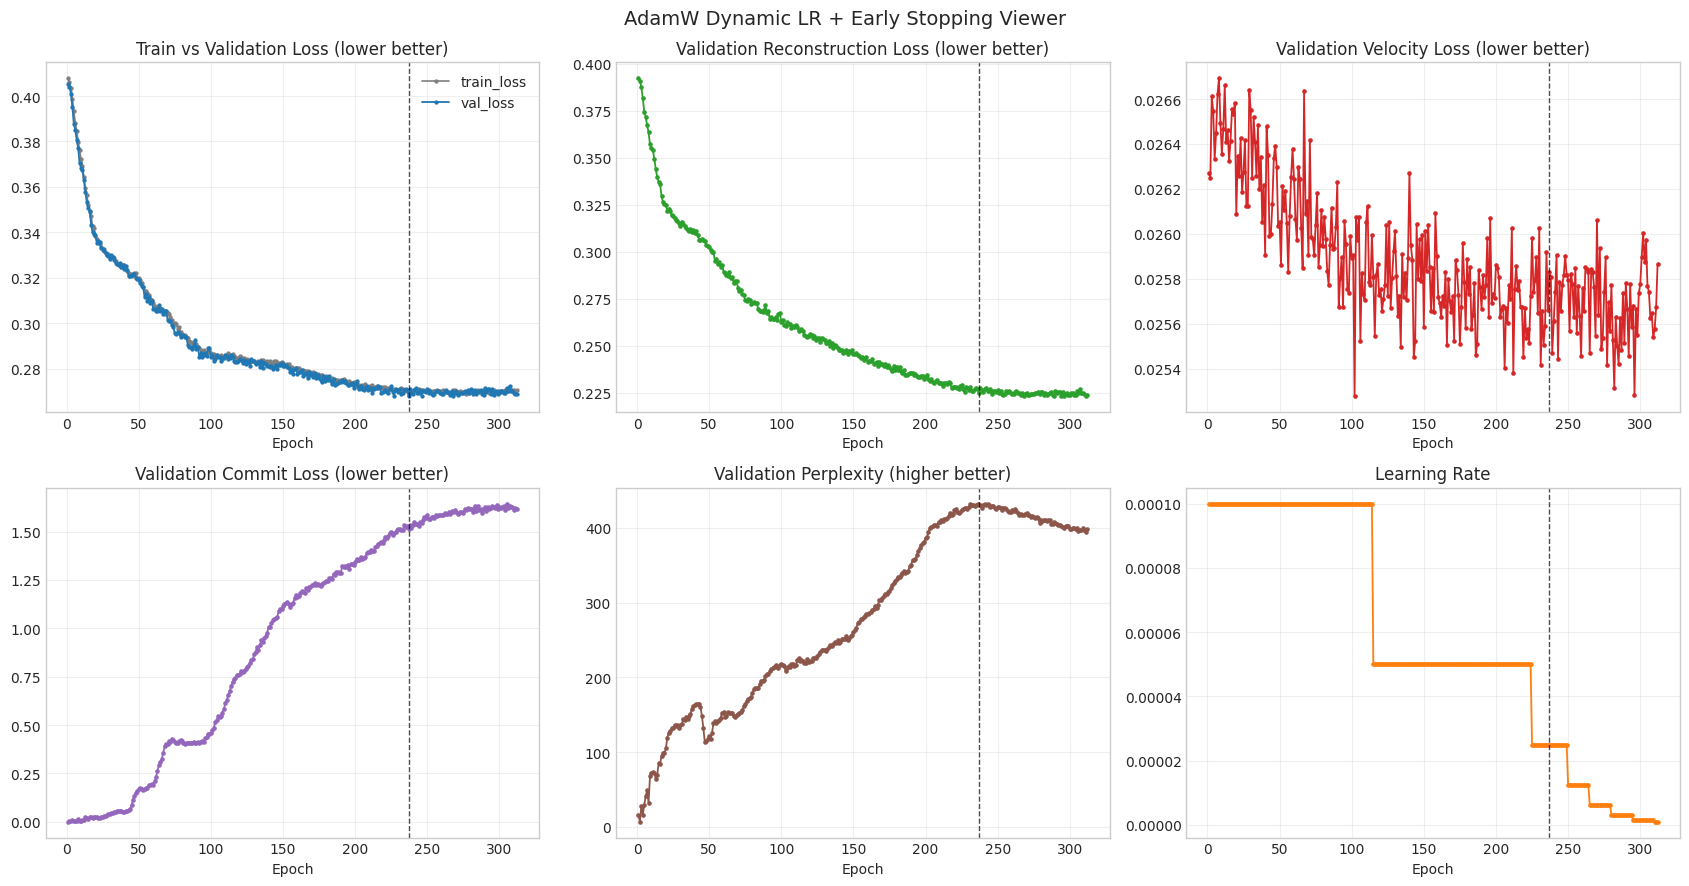

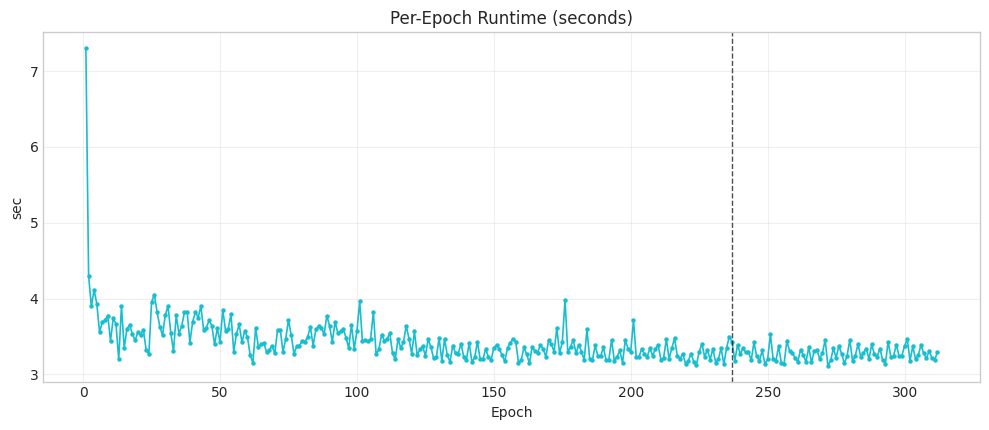

In [3]:
best_epoch = int(viewer_best_row['epoch'])
metric_specs = [
    ('val_loss', 'Validation Loss (lower better)', 'tab:blue'),
    ('val_recon', 'Validation Reconstruction Loss (lower better)', 'tab:green'),
    ('val_velocity', 'Validation Velocity Loss (lower better)', 'tab:red'),
    ('val_commit', 'Validation Commit Loss (lower better)', 'tab:purple'),
    ('val_perplexity', 'Validation Perplexity (higher better)', 'tab:brown'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

axes[0].plot(viewer_df['epoch'], viewer_df['train_loss'], marker='o', markersize=2.1, linewidth=1.2, color='tab:gray', label='train_loss')
axes[0].plot(viewer_df['epoch'], viewer_df['val_loss'], marker='o', markersize=2.1, linewidth=1.3, color='tab:blue', label='val_loss')
axes[0].axvline(best_epoch, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
axes[0].set_title('Train vs Validation Loss (lower better)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for ax_idx, (metric, title, color) in enumerate(metric_specs[1:], start=1):
    ax = axes[ax_idx]
    ax.plot(viewer_df['epoch'], viewer_df[metric], marker='o', markersize=2.3, linewidth=1.3, color=color)
    ax.axvline(best_epoch, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

axes[-1].plot(viewer_df['epoch'], viewer_df['lr'], marker='o', markersize=2.3, linewidth=1.3, color='tab:orange')
axes[-1].axvline(best_epoch, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
axes[-1].set_title('Learning Rate')
axes[-1].set_xlabel('Epoch')
axes[-1].grid(True, alpha=0.3)

plt.suptitle('AdamW Dynamic LR + Early Stopping Viewer', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(viewer_df['epoch'], viewer_df['epoch_sec'], marker='o', markersize=2.2, linewidth=1.2, color='tab:cyan')
ax.axvline(best_epoch, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_title('Per-Epoch Runtime (seconds)')
ax.set_xlabel('Epoch')
ax.set_ylabel('sec')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [4]:
print('Found full-clip panel MP4s:', len(viewer_panel_mp4s))
if len(viewer_panel_mp4s) == 0:
    print('No full-clip RGB+reconstruction MP4s found.')
else:
    for i, mp4_path in enumerate(viewer_panel_mp4s, start=1):
        try:
            artifact_rel = mp4_path.relative_to(VIEWER_ARTIFACT_DIR.parent)
        except Exception:
            artifact_rel = mp4_path.name
        display(Markdown(
            f'## Full-Clip Render {i}: `{mp4_path.name}`\n'
            f'- artifact-relative path: `{artifact_rel}`'
        ))
        display(Video(filename=str(mp4_path.resolve()), embed=True, html_attributes='controls'))



Found full-clip panel MP4s: 1


## Full-Clip Render 1: `2SHrot4ryPk_2-5-rgb_front__epoch0225__rgb_recon.mp4`
- artifact-relative path: `04_adamw_dynamiclr_earlystop_1000/fullclip_val_rgb_recon_mp4/2SHrot4ryPk_2-5-rgb_front__epoch0225__rgb_recon.mp4`